# Sentiment analysis

### Configuration

In [4]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors
from collections import defaultdict, Counter
from sklearn.feature_extraction.text import CountVectorizer
import string
import re
import nltk
import time
import joblib
import mlflow
import mlflow.sklearn
from pathlib import Path
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

In [5]:
mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("sentiment_analysis_model_comparison")

MODEL_DIR = Path("models")
MODEL_DIR.mkdir(exist_ok=True)

### Datasets

In [6]:
cwd=Path.cwd()
DATASET_PATH = cwd / "datasets/sentiment_analysis"  
first_dataset = pd.read_csv(DATASET_PATH / "first_dataset.csv", header=None, names=["sentiment", "text"])
second_dataset_1 = pd.read_csv(DATASET_PATH / "second_dataset1.csv")
second_dataset_2 = pd.read_csv(DATASET_PATH / "second_dataset2.csv")

In [7]:
print(f"Dimnsions of FinancialPhraseBank dataset: {first_dataset.shape}")
print(f"Dimnsions of The Twitter Financial News train dataset: {second_dataset_1.shape}")
print(f"Dimnsions of The Twitter Financial News test dataset: {second_dataset_2.shape}")

Dimnsions of FinancialPhraseBank dataset: (4846, 2)
Dimnsions of The Twitter Financial News train dataset: (9543, 2)
Dimnsions of The Twitter Financial News test dataset: (2388, 2)


In [8]:
first_dataset.head()

,sentiment,text
0,neutral,"According to Gran , the company has no plans t..."
1,neutral,Technopolis plans to develop in stages an area...
2,negative,The international electronic industry company ...
3,positive,With the new production plant the company woul...
4,positive,According to the company 's updated strategy f...


In [9]:
second_dataset_1.head()

,text,label
0,$BYND - JPMorgan reels in expectations on Beyo...,0
1,$CCL $RCL - Nomura points to bookings weakness...,0
2,"$CX - Cemex cut at Credit Suisse, J.P. Morgan ...",0
3,$ESS: BTIG Research cuts to Neutral https://t....,0
4,$FNKO - Funko slides after Piper Jaffray PT cu...,0


In [10]:
second_dataset_2.head()

,text,label
0,$ALLY - Ally Financial pulls outlook https://t...,0
1,"$DELL $HPE - Dell, HPE targets trimmed on comp...",0
2,$PRTY - Moody's turns negative on Party City h...,0
3,$SAN: Deutsche Bank cuts to Hold,0
4,$SITC: Compass Point cuts to Sell,0


In [11]:
print(f"Data types in the FinancialPhraseBank dataset:")
print(f"===========================================================")
print(first_dataset.dtypes)
print(f"===========================================================")
print(f"Data types in The Twitter Financial News train dataset:")
print(f"===========================================================")
print(second_dataset_1.dtypes)
print(f"===========================================================")
print(f"Data types in The Twitter Financial News test dataset:")
print(f"===========================================================")
print(second_dataset_2.dtypes)

Data types in the FinancialPhraseBank dataset:
sentiment    object
text         object
dtype: object
Data types in The Twitter Financial News train dataset:
text     object
label     int64
dtype: object
Data types in The Twitter Financial News test dataset:
text     object
label     int64
dtype: object


The Financial PhraseBank dataset contains textual financial statements labeled with categorical sentiment values, while the Twitter Financial News dataset contains text samples with numerical sentiment labels. Since the datasets use different label formats, a preprocessing step is required to unify the sentiment representation before merging them into a single training corpus.

In [12]:
print(f"Missing values:")
print(f"================================")
print(f"The Financial PhraseBank dataset:\n{first_dataset.isna().sum()}")
print(f"The Twitter Financial News train dataset:\n{second_dataset_1.isna().sum()}")
print(f"The Twitter Financial News test dataset:\n{second_dataset_2.isna().sum()}")

Missing values:
The Financial PhraseBank dataset:
sentiment    0
text         0
dtype: int64
The Twitter Financial News train dataset:
text     0
label    0
dtype: int64
The Twitter Financial News test dataset:
text     0
label    0
dtype: int64


There is no missing values so we don't have to handle them.

In [13]:
print(f"Values in FinancialPhraseBank dataset:")
print(first_dataset['sentiment'].value_counts())

Values in FinancialPhraseBank dataset:
sentiment
neutral     2879
positive    1363
negative     604
Name: count, dtype: int64


In [14]:
print(f"Values in The Twitter Financial News train dataset:")
print(second_dataset_1['label'].value_counts())
print
print(f"Values in The Twitter Financial News test dataset:")
print(second_dataset_2['label'].value_counts())


Values in The Twitter Financial News train dataset:
label
2    6178
1    1923
0    1442
Name: count, dtype: int64
Values in The Twitter Financial News test dataset:
label
2    1566
1     475
0     347
Name: count, dtype: int64


In [15]:
second_dataset_1 = second_dataset_1[['text', 'label']].copy()
second_dataset_2 = second_dataset_2[['text', 'label']].copy()

label_map_twitter = {
    0: 'negative', 
    1: 'positive', 
    2: 'neutral'
}

second_dataset_1 = second_dataset_1.rename(columns={'label': 'sentiment'})
second_dataset_1['sentiment'] = second_dataset_1['sentiment'].map(label_map_twitter)

second_dataset_2 = second_dataset_2.rename(columns={'label': 'sentiment'})
second_dataset_2['sentiment'] = second_dataset_2['sentiment'].map(label_map_twitter)
print(f"Values in The Twitter Financial News train dataset after mapping:")
print(second_dataset_1['sentiment'].value_counts())
print(f"=================================================================")
print(f"Values in The Twitter Financial News test dataset after mapping:")
print(second_dataset_2['sentiment'].value_counts())

Values in The Twitter Financial News train dataset after mapping:
sentiment
neutral     6178
positive    1923
negative    1442
Name: count, dtype: int64
Values in The Twitter Financial News test dataset after mapping:
sentiment
neutral     1566
positive     475
negative     347
Name: count, dtype: int64


After this we can merge all the datasets

In [16]:
combined_df = pd.concat([
    first_dataset,
    second_dataset_1,
    second_dataset_2
], ignore_index=True)

print(f"New dataset has {combined_df.shape[0]} rows and {combined_df.shape[1]} columns.")
print("=========================================")
print(combined_df['sentiment'].value_counts())

New dataset has 16777 rows and 2 columns.
sentiment
neutral     10623
positive     3761
negative     2393
Name: count, dtype: int64


### Exploratory Data Analysis

In [17]:
print(f"In dataset {"exists duplicates!" if combined_df.duplicated().sum()>0 else "doesn't exist duplicates!"}")

In dataset exists duplicates!


In [18]:
combined_df = combined_df.drop_duplicates()
print(f"In dataset {"exists duplicates" if combined_df.duplicated().sum()>0 else "doesn't exist duplicates!"}")

In dataset doesn't exist duplicates!


In [19]:
# we will make new DataFrame for EDA purpouse
eda_df=combined_df.copy()

In [20]:
# definition of sentiment colors and seaborn theme
colors = {
    'positive': '#99d8c9',   # baby green
    'negative': '#c994c7',   # baby pink
    'neutral':  '#e7e1ef'    # nude/neutral
}
sns.set_theme(style="ticks", font_scale=1.1)

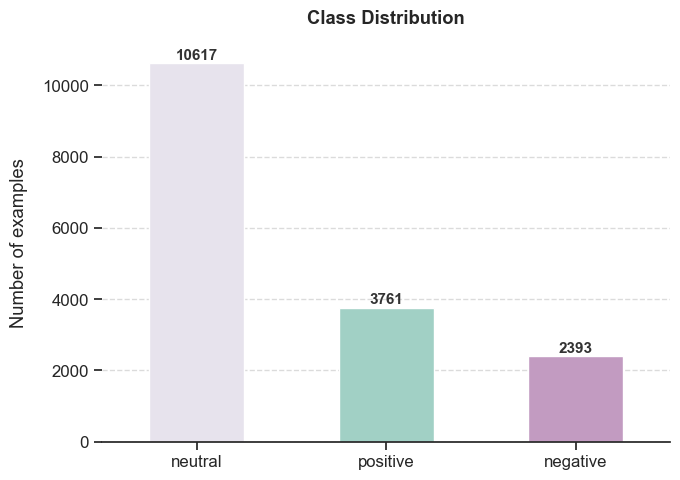

In [21]:
fig, ax = plt.subplots(figsize=(7, 5))

class_counts = eda_df['sentiment'].value_counts().reset_index()
class_counts.columns = ['sentiment', 'count']

sns.barplot(
    data=class_counts,
    x='sentiment',
    y='count',
    hue='sentiment',    
    palette=colors,
    legend=False,           
    width=0.5,
    ax=ax
)

for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 20,
        f'{int(bar.get_height())}',
        ha='center', va='bottom',
        fontsize=11, fontweight='bold', color='#333333'
    )

ax.set_xlabel('')
ax.set_ylabel('Number of examples', labelpad=10)
ax.set_title('Class Distribution', pad=15, fontweight='bold')
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

sns.despine(left=True)   
plt.tight_layout()
plt.show()

##### Class Distribution

Analysis of the dataset revealed an imbalanced class distribution, with the 
`neutral` class being the most represented, which is a common characteristic 
of sentiment datasets.

##### Handling Class Imbalance

Unlike classical classification problems where oversampling (e.g., 
SMOTE) or undersampling are commonly applied, these techniques are not suitable 
for NLP tasks. Interpolating between TF-IDF vectors does not produce semantically 
meaningful text, as the resulting synthetic vectors do not correspond to any real 
linguistic expression.

Instead, class imbalance is addressed directly within both approaches. For 
Logistic Regression, the `class_weight='balanced'` parameter is used, which 
automatically assigns higher weights to minority classes during training. For 
BERT fine-tuning, the same principle is applied through weighted cross-entropy 
loss, where class weights are incorporated directly into the loss function. In 
both cases, weights are computed as:

$$w_k = \frac{n}{K \cdot n_k}$$

where $n$ is the total number of samples, $K$ is the number of classes, and 
$n_k$ is the number of samples in class $k$. This penalizes misclassifications 
of minority classes more heavily, preventing both models from defaulting to the 
dominant neutral class.

Since accuracy can be misleading in imbalanced settings, macro-averaged F1 
score is used as the primary evaluation metric throughout both approaches, as 
it assigns equal importance to each class regardless of its size.

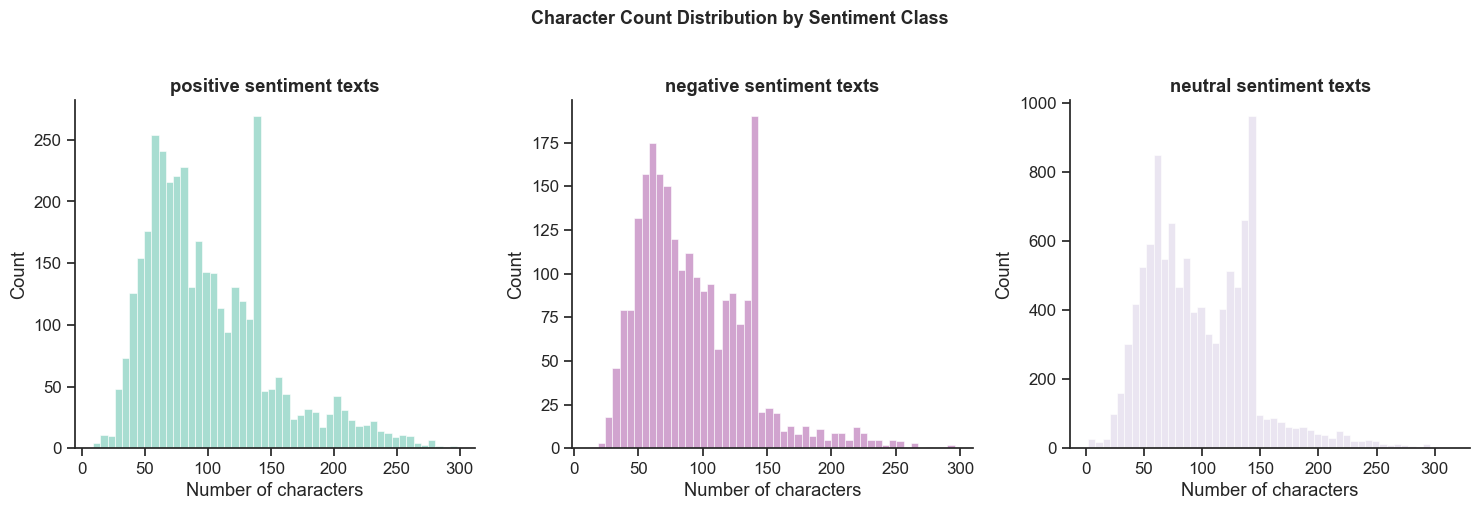

In [22]:
eda_df['char_count'] = eda_df['text'].astype(str).apply(len)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, sentiment in zip(axes, ['positive', 'negative', 'neutral']):
    data = eda_df[eda_df['sentiment'] == sentiment]['char_count']
    sns.histplot(data, bins=50, ax=ax,
                 color=colors[sentiment],
                 alpha=0.85, edgecolor='white', linewidth=0.4)
    ax.set_title(f'{sentiment} sentiment texts', fontweight='bold')
    ax.set_xlabel('Number of characters')
    ax.set_ylabel('Count')
    sns.despine(ax=ax)

fig.suptitle('Character Count Distribution by Sentiment Class',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

- All three classes show a similar distribution shape, peaking around 100–150 characters
- Neutral class has noticeably more examples (y-axis goes to 1000 vs ~250 for positive), consistent with class imbalance seen earlier
- Right-skewed distributions suggest most texts are short, with few very long ones

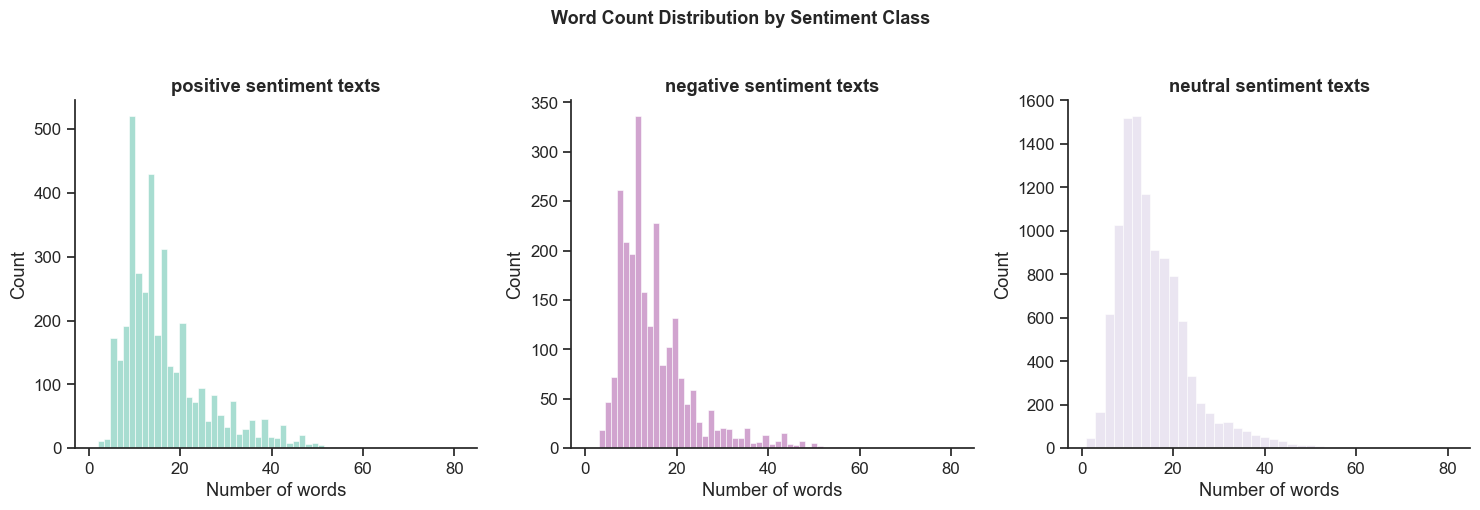

In [23]:
eda_df['word_count'] = eda_df['text'].apply(lambda x: len(str(x).split()))

fig, axes = plt.subplots(1, 3, figsize=(15, 5),sharex=True)

for ax, sentiment in zip(axes, ['positive', 'negative', 'neutral']):
    data = eda_df[eda_df['sentiment'] == sentiment]['word_count']
    sns.histplot(data, bins=40, ax=ax,
                 color=colors[sentiment],
                 alpha=0.85, edgecolor='white', linewidth=0.4)
    ax.set_title(f'{sentiment} sentiment texts', fontweight='bold')
    ax.set_xlabel('Number of words')
    ax.set_ylabel('Count')
    sns.despine(ax=ax)

fig.suptitle('Word Count Distribution by Sentiment Class',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

The distributions of word counts across sentiment classes are similar and right-skewed, indicating that most texts are relatively short. No significant differences in length are observed between classes, suggesting that word count alone is not a strong discriminative feature for sentiment classification.

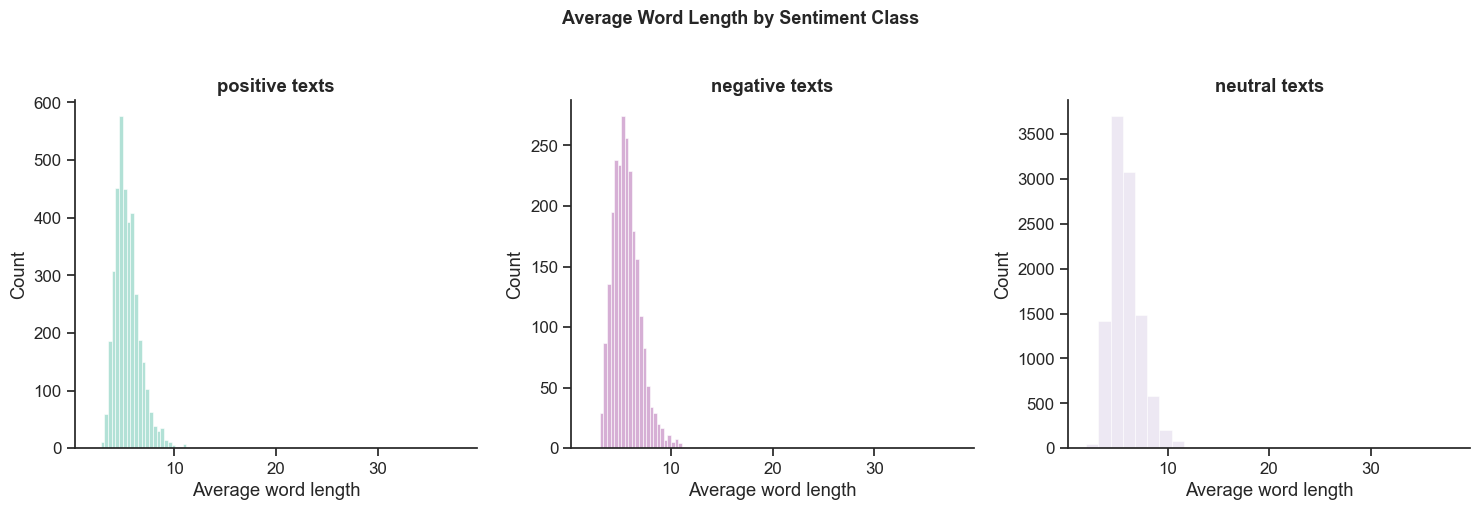

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5),sharex=True)

for ax, sentiment in zip(axes, ['positive', 'negative', 'neutral']):
    avg_word_len = eda_df[eda_df['sentiment'] == sentiment]['text'].str.split()\
        .apply(lambda x: np.mean([len(w) for w in x]) if x else 0)
    sns.histplot(avg_word_len, ax=ax,
                 color=colors[sentiment],
                 bins=30, edgecolor='white', linewidth=0.4)
    ax.set_title(f'{sentiment} texts', fontweight='bold')
    ax.set_xlabel('Average word length')
    ax.set_ylabel('Count')
    sns.despine(ax=ax)

fig.suptitle('Average Word Length by Sentiment Class',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

All three classes have nearly identical average word length distributions, centered around 5–8 characters per word. This suggests that word length is not a distinguishing feature between sentiment classes and will likely carry little predictive power for the model.

In [25]:
def create_corpus(df, sentiment):
    corpus = []
    for text in eda_df[eda_df['sentiment'] == sentiment]['text'].str.split():
        for word in text:
            corpus.append(word)
    return corpus

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\WIN10\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


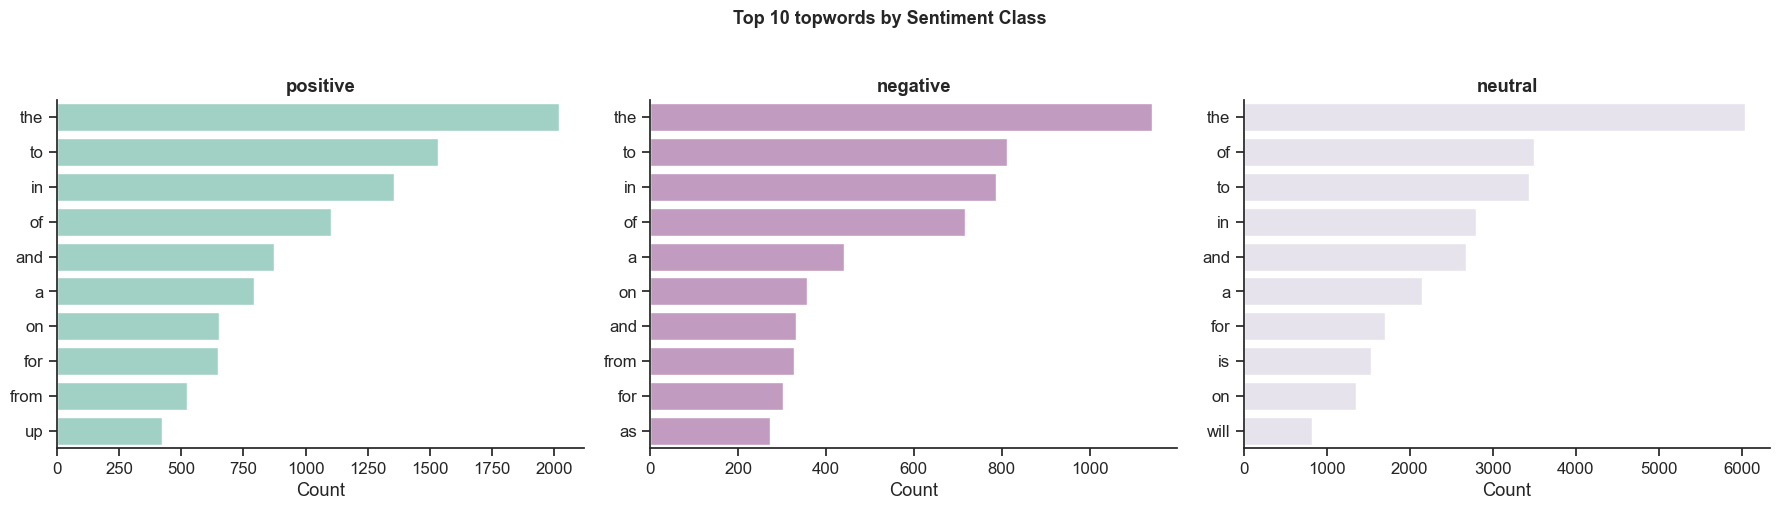

In [26]:
nltk.download('stopwords')

from nltk.corpus import stopwords

stop = set(stopwords.words('english'))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, sentiment in zip(axes, ['positive', 'negative', 'neutral']):
    corpus = create_corpus(eda_df, sentiment)
    dic = defaultdict(int)
    for word in corpus:
        if word.lower() in stop:
            dic[word.lower()] += 1

    top = sorted(dic.items(), key=lambda x: x[1], reverse=True)[:10]
    words, counts = zip(*top)

    sns.barplot(x=list(counts), y=list(words), ax=ax,
                color=colors[sentiment], orient='h')
    ax.set_title(f'{sentiment}', fontweight='bold')
    ax.set_xlabel('Count')
    ax.set_ylabel('')
    sns.despine(ax=ax)

fig.suptitle('Top 10 topwords by Sentiment Class',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

- "the", "to", "in", "of" dominate across all classes — expected for English
- Very similar stopword profiles across classes, meaning stopwords alone carry little sentiment signal
- Confirms importance of removing stopwords before modeling

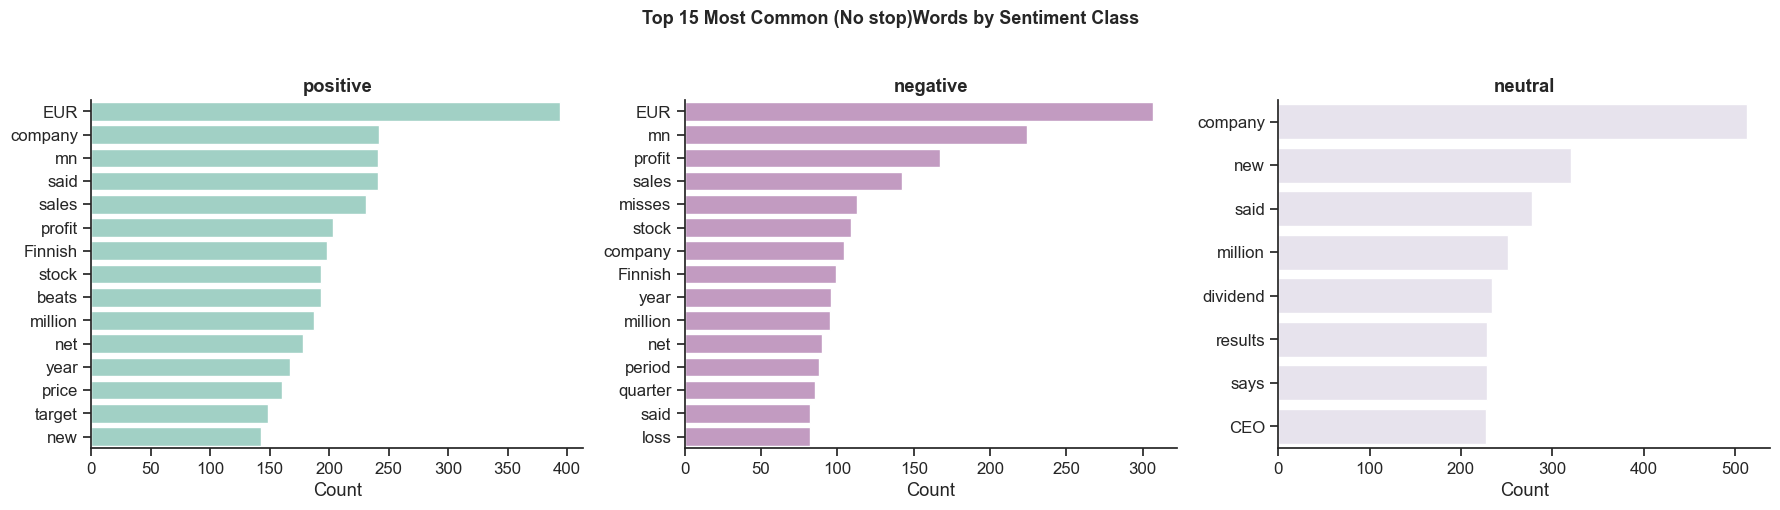

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, sentiment in zip(axes, ['positive', 'negative', 'neutral']):
    corpus = create_corpus(eda_df, sentiment)
    counter = Counter(corpus)

    words, counts = [], []
    for word, count in counter.most_common(50):
        if word.lower() not in stop and word.isalpha():
            words.append(word)
            counts.append(count)
            if len(words) == 15:
                break

    sns.barplot(x=counts, y=words, ax=ax,
                color=colors[sentiment], orient='h')
    ax.set_title(f'{sentiment}', fontweight='bold')
    ax.set_xlabel('Count')
    ax.set_ylabel('')
    sns.despine(ax=ax)

fig.suptitle('Top 15 Most Common (No stop)Words by Sentiment Class',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

- Positive class has unique words like "beats" — implying exceeding expectations
- Negative class has "misses", "loss" — implying underperformance
- Neutral class is more generic: "company", "said", "new", "dividend" — descriptive, non-evaluative language

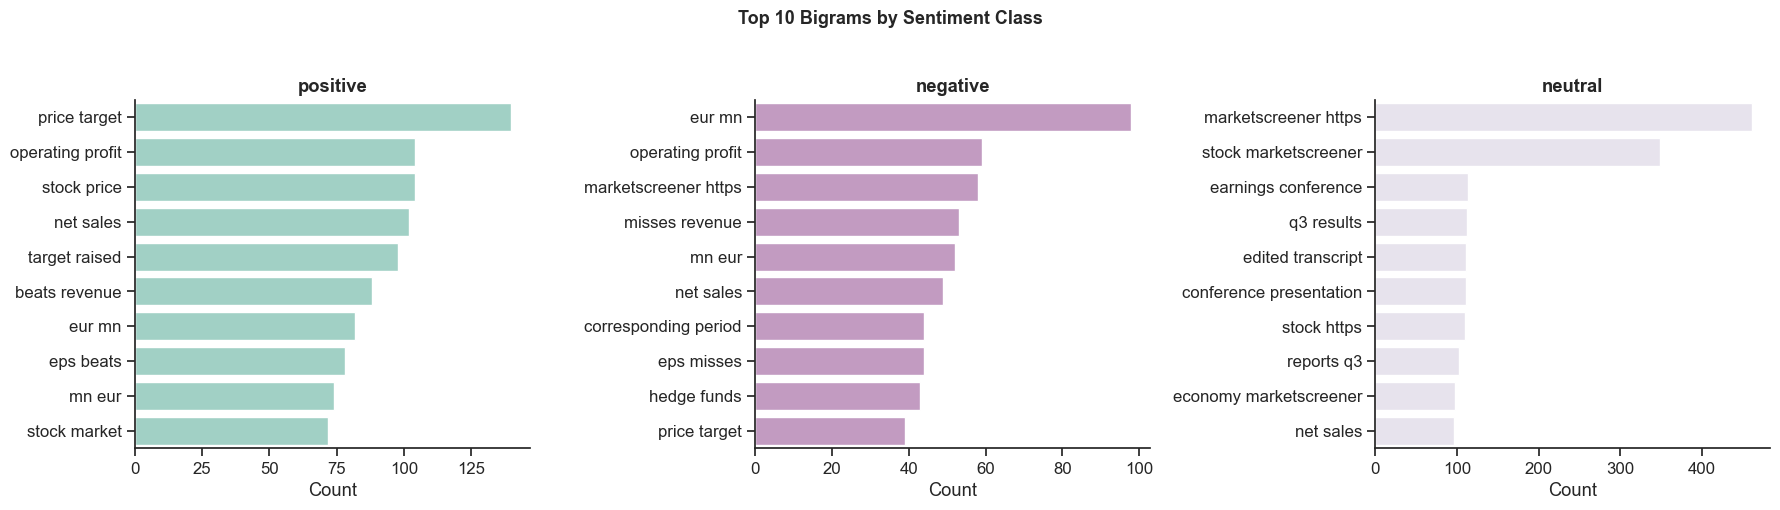

In [28]:
def get_top_bigrams(corpus, n=10):
    vec = CountVectorizer(ngram_range=(2, 2),
                          stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx])
                  for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:n]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, sentiment in zip(axes, ['positive', 'negative', 'neutral']):
    corpus = eda_df[eda_df['sentiment'] == sentiment]['text'].tolist()
    top_bigrams = get_top_bigrams(corpus, n=10)
    words, counts = map(list, zip(*top_bigrams))

    sns.barplot(x=counts, y=words, ax=ax,
                color=colors[sentiment], orient='h')
    ax.set_title(f'{sentiment}', fontweight='bold')
    ax.set_xlabel('Count')
    ax.set_ylabel('')
    sns.despine(ax=ax)

fig.suptitle('Top 10 Bigrams by Sentiment Class',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

- Positive bigrams: "price target", "target raised", "beats revenue" — forward-looking, optimistic
- Negative bigrams: "misses revenue", "eps misses", "hedge funds" — performance shortfalls
- Neutral bigrams: "marketscreener https", "earnings conference", "edited transcript" — source/event references, confirming neutral texts are often factual reports
- Bigrams reveal domain context more clearly than unigrams alone and that's why we will include them in TD-IDF vector representation of texts

### Natural Languague Preprocessing

This step is required for later step where we will vectorize each text.

In [29]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer

In [30]:
nltk.download('wordnet')
nltk.download('punkt_tab')

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\WIN10\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\WIN10\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [31]:
def remove_urls(text):
    """Removes URLs from text"""
    return re.compile(r'https?://\S+|www\.\S+').sub(r'', text)

def remove_html(text):
    """Removes HTML tags from text"""
    return re.compile(r'<.*?>').sub(r'', text)

def remove_mentions_and_rt(text):
    """Removes retweet tags (RT) and @mentions"""
    text = re.sub(r'\bRT\b', '', text)
    text = re.sub(r'@\w+', '', text)
    return text

def remove_hashtags(text):
    """Removes # symbol but keeps the word"""
    return re.sub(r'#', '', text)

def remove_square_brackets(text):
    """Removes text contained within square brackets"""
    return re.sub(r'\[.*?\]', '', text)

def remove_breaklines(text):
    """Removes breakline and carriage return characters"""
    return re.sub(r'[\n\r]', ' ', text)

def remove_dates(text):
    """Removes date patterns from text"""
    pattern = r'([0-2][0-9]|(3)[0-1])(\/|\.)(((0)[0-9])|((1)[0-2]))(\/|\.)\d{2,4}'
    return re.sub(pattern, '', text)

def remove_money(text):
    """Removes monetary amounts and currency symbols"""
    return re.sub(r'[\$£€]\s?\d+([.,]\d+)?|\d+([.,]\d+)?\s?[\$£€]', '', text)

def remove_numbers(text):
    """Removes words containing numbers"""
    return re.sub(r'\w*\d\w*', '', text)

def remove_punctuation(text):
    """Removes all punctuation marks"""
    return text.translate(str.maketrans('', '', string.punctuation))

In [32]:
def tokenize_text(text):
    """
    Tokenizes text into a list of individual word tokens.
    This is the transition point from string to list.
    
    Input:  string → "apple reported record profit"
    Output: list   → ["apple", "reported", "record", "profit"]
    """
    return word_tokenize(text)

In [33]:
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def remove_stopwords_tokens(tokens):
    """
    Removes stopwords from a list of tokens.
    
    Input:  list → ["apple", "the", "reported", "a", "profit"]
    Output: list → ["apple", "reported", "profit"]
    """
    return [token for token in tokens if token not in stop_words]

def stem_tokens(tokens):
    """
    Applies Porter stemming to a list of tokens.
    
    Input:  list → ["reported", "earning", "profits"]
    Output: list → ["report", "earn", "profit"]
    """
    return [stemmer.stem(token) for token in tokens]

In [34]:
# because TD-IDF works with strings
def tokens_to_string(tokens):
    """
    Joins a list of tokens back into a single string.

    Input:  list   → ["apple", "report", "earn"]
    Output: string → "apple report earn"
    """
    return ' '.join(tokens)

In [35]:
def preprocess_text(text):
    """
    Applies a complete text preprocessing pipeline.
    Parameters:
        text (str): Raw input text
    Returns:
        str: Cleaned and preprocessed text
    """
    text = str(text).lower()
    text = remove_urls(text)
    text = remove_html(text)
    text = remove_mentions_and_rt(text)
    text = remove_hashtags(text)
    text = remove_square_brackets(text)
    text = remove_breaklines(text)
    text = remove_dates(text)
    text = remove_money(text)
    text = remove_numbers(text)
    text = remove_punctuation(text)

    tokens = tokenize_text(text)

    tokens = remove_stopwords_tokens(tokens)
    tokens = stem_tokens(tokens)

    return tokens_to_string(tokens)

In [36]:
combined_df['clean_text'] = combined_df['text'].apply(preprocess_text)

# Verify results on sample rows
print("Sample results before and after preprocessing:")
print("=" * 60)
for idx in [0, 100, 500]:
    print(f"\nORIGINAL:\n{combined_df['text'].iloc[idx]}")
    print(f"\nCLEAN:\n{combined_df['clean_text'].iloc[idx]}")
    print("-" * 60)

Sample results before and after preprocessing:

ORIGINAL:
According to Gran , the company has no plans to move all production to Russia , although that is where the company is growing .

CLEAN:
accord gran compani plan move product russia although compani grow
------------------------------------------------------------

ORIGINAL:
Both operating profit and turnover for the three-month period increased , respectively from EUR0 .9 m and EUR8 .3 m , as compared to the corresponding period in 2005 .

CLEAN:
oper profit turnov threemonth period increas respect compar correspond period
------------------------------------------------------------

ORIGINAL:
One of the challenges in the oil production in the North Sea is scale formation that can plug pipelines and halt production .

CLEAN:
one challeng oil product north sea scale format plug pipelin halt product
------------------------------------------------------------


### Train and test split

In [37]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    combined_df,
    test_size=0.2,
    random_state=42,
    stratify=combined_df['sentiment']  # čuva proporciju klasa
)

print(f"Train size: {len(train_df)}")
print(f"Test size:  {len(test_df)}")
print(f"\nTrain sentiment distribution:\n{train_df['sentiment'].value_counts()}")
print(f"\nTest sentiment distribution:\n{test_df['sentiment'].value_counts()}")


train_df.to_csv('datasets/sentiment_analysis/train_set.csv', index=False)
test_df.to_csv('datasets/sentiment_analysis/test_set.csv', index=False)


Train size: 13416
Test size:  3355

Train sentiment distribution:
sentiment
neutral     8493
positive    3009
negative    1914
Name: count, dtype: int64

Test sentiment distribution:
sentiment
neutral     2124
positive     752
negative     479
Name: count, dtype: int64


### TF-IDF Vectorization

TF-IDF (Term Frequency - Inverse Document Frequency) is a numerical statistic 
that reflects how important a word is to a document within a collection. 
It is one of the most widely used text representation methods in NLP and 
information retrieval.

The TF-IDF score is the product of two terms:

**Term Frequency (TF)** — measures how often a word appears in a document.
A logarithmic scale is used to avoid over-weighting highly frequent words:

$$tf_{t,d} = 1 + \log_{10}(\text{count}(t,d)) \quad \text{if count} > 0, \text{ else } 0$$

**Inverse Document Frequency (IDF)** — measures how rare a word is across 
the entire corpus. Words that appear in every document (e.g. *the*, *a*) 
receive a low IDF score, while rare, informative words receive a high score:

$$idf_t = \log_{10}\frac{N}{df_t}$$

The final TF-IDF score combines both:

$$\text{tf-idf}(t,d) = tf_{t,d} \times idf_t$$


In [38]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

In [39]:
X_train = train_df['clean_text']
X_test  = test_df['clean_text']
y_train = train_df['sentiment']
y_test  = test_df['sentiment']

tfidf_vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf  = tfidf_vectorizer.transform(X_test)

print(f"TF-IDF matrix: {X_train_tfidf.shape}")

TF-IDF matrix: (13416, 5000)


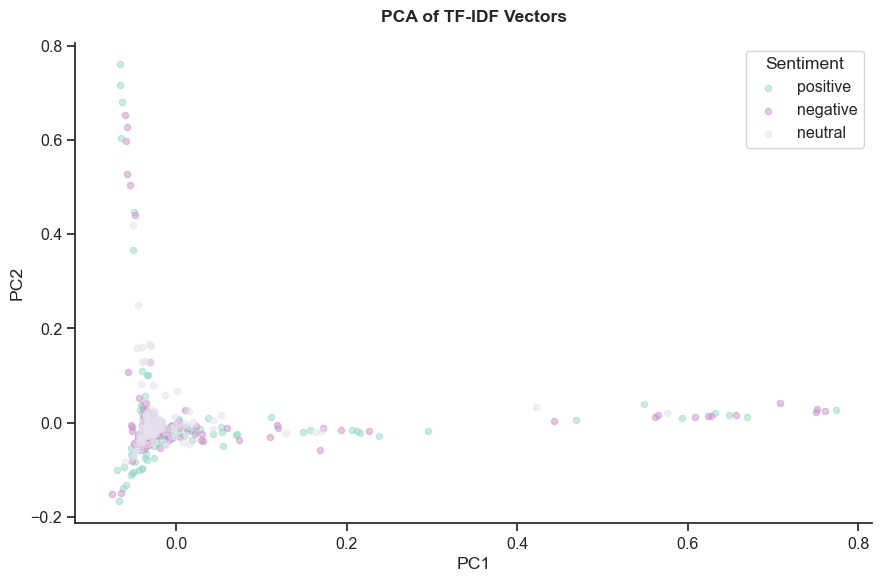

In [40]:
# We will work on sample
n_per_class = 200  # 200 samples per class= 600 samles total

sample_idx = []
for sentiment in ['positive', 'negative', 'neutral']:
    idx = np.where(y_train.values == sentiment)[0]
    sampled = np.random.choice(idx, n_per_class, replace=False)
    sample_idx.extend(sampled)

sample_idx = np.array(sample_idx)

X_sample = X_train_tfidf[sample_idx].toarray()
y_sample = y_train.values[sample_idx]

# PCA implementation
def compute_pca(X, n_components=2):
    X_demeaned = X - np.mean(X, axis=0)
    covariance_matrix = np.cov(X_demeaned.T)
    eigen_vals, eigen_vecs = np.linalg.eigh(covariance_matrix)
    idx_sorted_decreasing = np.argsort(eigen_vals)[::-1]
    eigen_vecs_sorted = eigen_vecs[:, idx_sorted_decreasing]
    eigen_vecs_subset = eigen_vecs_sorted[:, :n_components]
    X_reduced = np.dot(X_demeaned, eigen_vecs_subset)
    return X_reduced

X_pca = compute_pca(X_sample, n_components=2)

sns.set_theme(style="ticks", font_scale=1.05)
fig, ax = plt.subplots(figsize=(9, 6))

for sentiment in ['positive', 'negative', 'neutral']:
    mask = y_sample == sentiment
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               label=sentiment,
               color=colors[sentiment],
               alpha=0.5, s=20)

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('PCA of TF-IDF Vectors', fontweight='bold', pad=15)
ax.legend(title='Sentiment')
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

##### PCA Visualization of TF-IDF Vectors

The PCA plot above reveals a typical pattern for sparse, high-dimensional text data —
most points are compressed near the origin with no clear separation between sentiment 
classes. This is expected, and stems from a few key limitations:

- **High sparsity** — TF-IDF matrices are mostly zeros, and PCA relies on variance 
  to find structure, making it poorly suited for this type of data
- **Euclidean vs. cosine distance** — PCA operates on Euclidean distance, while text 
  similarity is better captured by cosine similarity
- **Unsupervised nature** — PCA has no knowledge of class labels, so it does not 
  optimize for sentiment separability

##### A Better Alternative: Truncated SVD (LSA)

We therefore switch to **Truncated Singular Value Decomposition (SVD)**, also known 
as Latent Semantic Analysis (LSA) in NLP:

- Works directly on **sparse matrices** — no memory-expensive densification needed
- Captures **latent semantic structure** in text
- Standard choice for dimensionality reduction of TF-IDF data

Explained variance: 1.95%


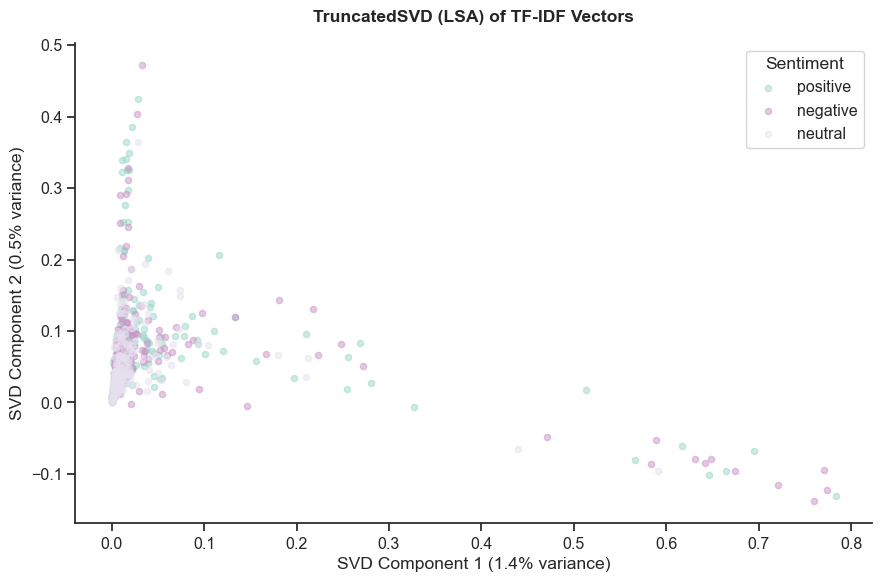

In [41]:
# SVD works directly on sparse matrix - without .toarray()
X_sample_sparse = X_train_tfidf[sample_idx]
y_sample = y_train.values[sample_idx]

# Fit SVD
svd = TruncatedSVD(n_components=2, random_state=42)
X_svd = svd.fit_transform(X_sample_sparse)

print(f"Explained variance: {svd.explained_variance_ratio_.sum():.2%}")

sns.set_theme(style="ticks", font_scale=1.05)
fig, ax = plt.subplots(figsize=(9, 6))

for sentiment in ['positive', 'negative', 'neutral']:
    mask = y_sample == sentiment
    ax.scatter(X_svd[mask, 0], X_svd[mask, 1],
               label=sentiment,
               color=colors[sentiment],
               alpha=0.5, s=20)

ax.set_xlabel(f'SVD Component 1 ({svd.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'SVD Component 2 ({svd.explained_variance_ratio_[1]:.1%} variance)')
ax.set_title('TruncatedSVD (LSA) of TF-IDF Vectors', fontweight='bold', pad=15)
ax.legend(title='Sentiment')
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

The SVD plot shows a similar pattern to PCA — no clear separation between 
sentiment classes, with an explained variance of only 2.06% across two components.

This result is not a failure of the method, but rather a reflection of the 
inherent limitations of bag-of-words representations for sentiment analysis:

- TF-IDF captures **word frequency**, not **semantic meaning**
- Financial sentiment is highly context-dependent — the same words can carry 
  different sentiment depending on surrounding context
- Two dimensions are simply insufficient to represent the complexity of 
  financial text

This motivates the use of **BERT**, a transformer-based model, which captures contextual meaning rather than word frequency, 
and is therefore expected to produce significantly better sentiment separation.

### Sentiment analysis with Logistic Regression

In [42]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV, StratifiedKFold

Logistic regression applies a sigmoid (or softmax for multiclass) function 
to a linear combination of input features to produce class probabilities.
While the underlying algorithm involves gradient descent to minimize 
cross-entropy loss, we use sklearn's optimized implementation here, 
as our focus is on comparing TF-IDF and BERT representations 
rather than the optimization procedure itself.

In [43]:
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf',   LogisticRegression(
                  max_iter=1000,
                  random_state=42,
                  class_weight='balanced' #because unbalanced target class
              ))
])

param_grid = {
    'tfidf__max_features': [3000, 5000, 10000], #max features in TD-IDF matrix
    'tfidf__ngram_range':  [(1, 1), (1, 2)], #we will consider unigrams and bigrams
    'clf__C':              [0.1, 1.0, 10.0],  #regularization
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) #because unbalanced target class

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='f1_macro',  
    cv=cv,
    n_jobs=-1,
    verbose=2
)

lr_train_start = time.perf_counter()

grid_search.fit(X_train, y_train)

lr_train_time = time.perf_counter() - lr_train_start

print("\n=== Logistic Regression - best params ===")
print(grid_search.best_params_)

best_lr = grid_search.best_estimator_

# num of parameters
lr_clf = best_lr.named_steps["clf"]
lr_n_params = lr_clf.coef_.size + lr_clf.intercept_.size

print(f"LR parameters: {lr_n_params:,}")
print(f"LR training time: {lr_train_time:.4f} seconds")

# Final evaluation + inference time
lr_inf_start = time.perf_counter()

y_pred = best_lr.predict(X_test)

lr_inference_time = time.perf_counter() - lr_inf_start
lr_inference_ms_per_sample = (lr_inference_time / len(X_test)) * 1000

print(f"LR inference time: {lr_inference_time:.4f} seconds")
print(f"LR inference time per sample: {lr_inference_ms_per_sample:.6f} ms")

Fitting 5 folds for each of 18 candidates, totalling 90 fits

=== Logistic Regression - best params ===
{'clf__C': 10.0, 'tfidf__max_features': 10000, 'tfidf__ngram_range': (1, 2)}
LR parameters: 30,003
LR training time: 19.3173 seconds
LR inference time: 0.0466 seconds
LR inference time per sample: 0.013899 ms


In [44]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
lr_report = classification_report(
    y_test,
    y_pred,
    output_dict=True
)


Classification Report:
              precision    recall  f1-score   support

    negative       0.61      0.68      0.64       479
     neutral       0.87      0.82      0.84      2124
    positive       0.62      0.68      0.65       752

    accuracy                           0.77      3355
   macro avg       0.70      0.73      0.71      3355
weighted avg       0.78      0.77      0.77      3355



In [45]:
lr_model_path = MODEL_DIR / "lr_tfidf_model.joblib"
joblib.dump(best_lr, lr_model_path)
lr_model_size_mb = lr_model_path.stat().st_size / (1024 ** 2)
lr_samples_per_second = len(X_test) / lr_inference_time

print(f"LR model size: {lr_model_size_mb:.4f} MB")

with mlflow.start_run(run_name="tfidf_logistic_regression"):
    mlflow.log_params(grid_search.best_params_)
    mlflow.log_param("model", "TF-IDF + Logistic Regression")
    mlflow.log_param("class_weight", "balanced")
    mlflow.log_param("cv", "StratifiedKFold_5")
    mlflow.log_param("hardware", "CPU")


    mlflow.log_metric("accuracy", lr_report["accuracy"])
    mlflow.log_metric("macro_f1", lr_report["macro avg"]["f1-score"])
    mlflow.log_metric("macro_precision", lr_report["macro avg"]["precision"])
    mlflow.log_metric("macro_recall", lr_report["macro avg"]["recall"])

    mlflow.log_metric("n_parameters", lr_n_params)
    mlflow.log_metric("model_size_mb", lr_model_size_mb)
    mlflow.log_metric("train_time_sec", lr_train_time)
    mlflow.log_metric("inference_time_sec", lr_inference_time)
    mlflow.log_metric("inference_ms_per_sample", lr_inference_ms_per_sample)
    mlflow.log_metric("samples_per_second", lr_samples_per_second)

    mlflow.sklearn.log_model(best_lr, "model")

LR model size: 0.5980 MB


2026/06/16 17:17:13 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


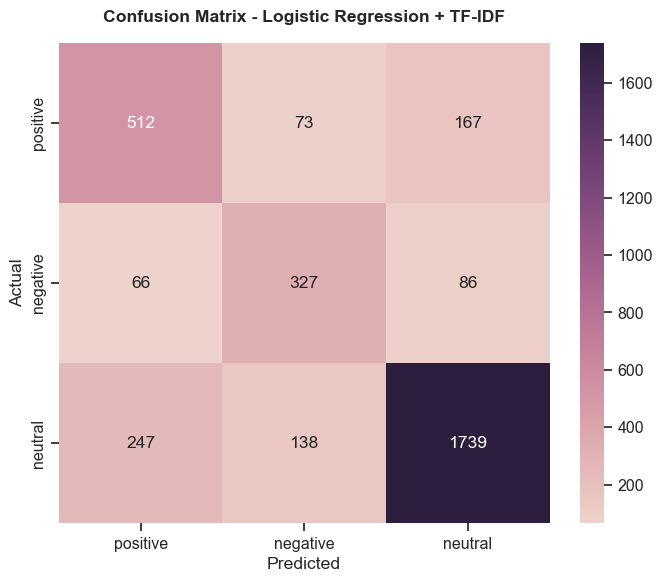

In [46]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=['positive', 'negative', 'neutral'])

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm,
            annot=True, fmt='d',
            xticklabels=['positive', 'negative', 'neutral'],
            yticklabels=['positive', 'negative', 'neutral'],
            cmap=sns.cubehelix_palette(as_cmap=True), ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix - Logistic Regression + TF-IDF',
             fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

GridSearchCV with 5-fold StratifiedKFold evaluated 18 parameter combinations, 
selecting the following optimal configuration:

- `C = 10.0` — low regularization, allowing the model to fit more complex patterns
- `max_features = 10000` — larger vocabulary captures more financial terminology
- `ngram_range = (1, 2)` — unigrams and bigrams preserve some phrase-level context

| Class | Precision | Recall | F1-score |
|---|---|---|---|
| Negative | 0.61 | 0.68 | 0.64 |
| Neutral | 0.87 | 0.82 | 0.84 |
| Positive | 0.62 | 0.68 | 0.65 |
| **Macro avg** | **0.70** | **0.73** | **0.71** |

The tuned model achieves a macro F1 of **0.71**, which serves as the 
baseline for comparison with FinBERT.

In [47]:
classes = list(best_lr.classes_)

rows = []

for label in ['negative', 'neutral', 'positive']:
    label_idx = classes.index(label)
    
    probs = best_lr.predict_proba(X_test)
    preds = best_lr.predict(X_test)
    
    candidate_indices = np.where(
        (y_test.values == label) & (preds == label)
    )[0]
    
    best_idx = candidate_indices[np.argmax(probs[candidate_indices, label_idx])]
    
    rows.append({
        "Original text": combined_df.loc[X_test.index[best_idx], "text"],
        "Actual label": y_test.values[best_idx],
        "Predicted label": preds[best_idx],
        "Probability": probs[best_idx, label_idx]
    })


wrong_indices = np.where(preds != y_test.values)[0]

if len(wrong_indices) > 0:
    wrong_confidences = probs[wrong_indices].max(axis=1)
    wrong_idx = wrong_indices[np.argmax(wrong_confidences)]
    
    rows.append({
        "Original text": combined_df.loc[X_test.index[wrong_idx], "text"],
        "Actual label": y_test.values[wrong_idx],
        "Predicted label": preds[wrong_idx],
        "Probability": probs[wrong_idx].max()
    })

examples_df = pd.DataFrame(rows)
examples_df["Probability"] = examples_df["Probability"].round(4)
pd.set_option('display.max_colwidth', None)

examples_df

,Original text,Actual label,Predicted label,Probability
0,AT&T shares sink after MoffettNathanson downgrade,negative,negative,0.9999
1,"3 Top-Performing Mutual Funds to Consider for Your Retirement Portfolio- February 06, 2020",neutral,neutral,0.9994
2,Why Diabetes Stock Insulet Jumped 13.3% in January -- After Soaring 116% in 2019,positive,positive,0.9999
3,The price of GMO soy is 5 % -7 % lower than that of non-GMO .,neutral,negative,0.9993


### Sentiment analysis with fine-tuned BERT

##### Environment Setup

Since BERT inference is computationally more demanding than the TF-IDF 
pipeline, this step was performed on Google Colab, which provides free access 
to GPU resources (NVIDIA T4). The training and test sets, previously saved 
during the data splitting step, were exported from the local environment, 
uploaded to Google Drive, and directly accessed within the Colab session.

In [1]:
!pip install transformers
!pip install torch

##### Configuration

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import time
import joblib
from pathlib import Path
 
from torch.utils.data import Dataset, DataLoader
from torch.nn import CrossEntropyLoss
from torch.optim import AdamW
 
from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    get_linear_schedule_with_warmup
)
 
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Available memory: "
          f"{torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")


Using device: cuda
GPU: Tesla T4
Available memory: 15.64 GB


In [4]:
train_df = pd.read_csv('/content/drive/MyDrive/diplomski/datasets/train_set.csv')
test_df  = pd.read_csv('/content/drive/MyDrive/diplomski/datasets/test_set.csv')

In [5]:
train_df, val_df = train_test_split(
    train_df,
    test_size=0.15,
    stratify=train_df["sentiment"],
    random_state=42
)

print(f"Train samples: {len(train_df)}")
print(f"Validation samples: {len(val_df)}")
print(f"Test samples: {len(test_df)}")

Train samples: 11403
Validation samples: 2013
Test samples: 3355


##### Model Overview

The second approach fine-tunes `bert-base-uncased` (Devlin et al., 2019) on the 
combined dataset for three-class sentiment classification. Rather than relying on sparse bag-of-words representations, BERT captures deep contextual semantics, making it well-suited for a dataset that spans 
both formal financial language and informal social media text.

Since `bert-base-uncased` was pre-trained on BookCorpus and English Wikipedia, 
it has no prior exposure to the target dataset, ensuring a clean experimental setup. 
A linear classification head is added on top of the [CLS] token representation 
and the entire model is trained end-to-end on the training set.

In [6]:
train_texts = train_df["text"].tolist()
val_texts   = val_df["text"].tolist()
test_texts  = test_df["text"].tolist()

train_labels_str = train_df["sentiment"].tolist()
val_labels_str   = val_df["sentiment"].tolist()
test_labels_str  = test_df["sentiment"].tolist()
 
print(f"Train samples: {len(train_df)}")
print(f"Validation samples: {len(val_df)}")
print(f"Test samples:  {len(test_df)}")

Train samples: 11403
Validation samples: 2013
Test samples:  3355


In [7]:
# BERT requires numeric labels — map sentiment strings to integers
# and keep the reverse mapping for converting predictions back to labels
label_to_id = {'positive': 0, 'negative': 1, 'neutral': 2}
id_to_label = {0: 'positive', 1: 'negative', 2: 'neutral'}
 

train_labels = [label_to_id[l] for l in train_labels_str]
val_labels   = [label_to_id[l] for l in val_labels_str]
test_labels  = [label_to_id[l] for l in test_labels_str]

As we saw before dataset is imbalanced so we will compute class weights to penalize
misclassifications of minority classes more heavily during training.

*Note: weights are converted to a float tensor and moved to GPU, since CrossEntropyLoss requires tensor input on the same device as the model.* 

In [8]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1, 2]),
    y=train_labels
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
print(f"\nClass weights: positive={class_weights[0]:.3f}, "
      f"negative={class_weights[1]:.3f}, neutral={class_weights[2]:.3f}")
 


Class weights: positive=1.487, negative=2.336, neutral=0.527


##### Input Representation and Tokenization

Unlike the TF-IDF pipeline, BERT receives raw, unprocessed text. Preprocessing 
steps such as stopword removal or stemming would degrade its performance, as BERT 
relies on the full linguistic context of the original sentence to generate 
meaningful representations.

Texts are tokenized using `BertTokenizer`, which applies WordPiece subword 
tokenization and automatically adds `[CLS]` and `[SEP]` special tokens. The 
`[CLS]` token serves as the aggregate sequence representation and is passed to 
the classification head. All sequences are padded or truncated to a maximum 
length of 128 tokens, which is sufficient for the short financial texts and 
tweets present in the dataset. An attention mask is generated alongside each 
sequence to ensure that padding tokens do not influence the model's representations.

In [9]:
MODEL_NAME = 'bert-base-uncased'
MAX_LENGTH = 128   # sufficient for short financial texts and tweets
BATCH_SIZE = 32    # optimal for T4 GPU

Tokenizing train, validation and test sets using the pre-trained `bert-base-uncased` tokenizer.

In [10]:
print(f"\nLoading tokenizer: {MODEL_NAME}...")
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)

def tokenize(texts):
    """
    Tokenizes a list of texts for BERT input.

    Applies WordPiece subword tokenization and produces:
    - input_ids:      token indices from BERT vocabulary
    - attention_mask: 1 for real tokens, 0 for padding tokens

    Special tokens are added automatically:
    - [CLS] at the beginning (used for classification)
    - [SEP] at the end

    Args:
        texts (list): list of raw input strings

    Returns:
        dict: input_ids and attention_mask as PyTorch tensors
    """
    return tokenizer(
        texts,
        padding=True,       # pad all sequences to the same length
        truncation=True,    # truncate sequences exceeding max_length
        max_length=MAX_LENGTH,
        return_tensors='pt' # return PyTorch tensors
    )

train_encodings = tokenize(train_texts)
val_encodings   = tokenize(val_texts)
test_encodings  = tokenize(test_texts)


Loading tokenizer: bert-base-uncased...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:122: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

##### Dataset and DataLoader

In [11]:
class SentimentDataset(Dataset):
    """
    Custom PyTorch Dataset that wraps tokenized texts and labels.
    Required by DataLoader to iterate over examples in batches.

    __getitem__ returns a single example as a dictionary of tensors,
    which PyTorch automatically stacks into batches during training.
    """
    def __init__(self, encodings, labels):
        self.input_ids      = encodings['input_ids']
        self.attention_mask = encodings['attention_mask']
        self.labels         = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids':      self.input_ids[idx],
            'attention_mask': self.attention_mask[idx],
            'labels':         self.labels[idx]
        }

train_dataset = SentimentDataset(train_encodings, train_labels)
val_dataset   = SentimentDataset(val_encodings, val_labels)
test_dataset  = SentimentDataset(test_encodings,  test_labels)

DataLoader splits the dataset into batches of size BATCH_SIZE.

In [12]:
# shuffle=True randomizes the order of training examples at each epoch to prevent the model from learning patterns based on sample ordering.
# shuffle=False for validation and test sets to preserve alignment between predictions and true labels
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)
 
print(f"Train batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches:  {len(test_loader)}")

Train batches: 357
Validation batches: 63
Test batches:  105


##### Model Initialization

The model is loaded using `BertForSequenceClassification`, a Hugging Face class 
that extends the pre-trained `bert-base-uncased` architecture with a classification 
head — a single linear layer that maps the 768-dimensional `[CLS]` token 
representation to three output classes. The classification head is randomly 
initialized and trained end-to-end together with all BERT parameters.

The `num_labels=3` argument configures the output layer for three-class 
classification. The label mappings (`id2label`, `label2id`) are stored within 
the model configuration, ensuring that the correct class names are preserved 
when the model is saved and reloaded for inference.

Upon loading, the model is transferred to the GPU via `.to(device)`. Since all 
parameters have `requires_grad=True`, the entire model (approximately 110 million 
parameters) is updated during fine-tuning.

In [13]:
print(f"\nLoading model: {MODEL_NAME}...")
model = BertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,        
    id2label=id_to_label,
    label2id=label_to_id
)
model = model.to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")


Loading model: bert-base-uncased...


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total parameters:     109,484,547
Trainable parameters: 109,484,547


##### Optimizer, Scheduler and Loss Function

The model is optimized using AdamW (Loshchilov and Hutter, 2019), a variant 
of the Adam optimizer with decoupled weight decay. Unlike standard Adam, AdamW 
applies L2 regularization directly to the weights rather than incorporating it 
into the gradient update, which has been shown to improve generalization in 
transformer-based models.

A learning rate of 2e-5 is used, consistent with the values recommended in 
the original BERT paper (Devlin et al., 2019). A small learning rate is 
essential for fine-tuning (a large value would overwrite the pre-trained 
representations and degrade performance).

A linear schedule with warmup is applied: the learning rate increases linearly 
from 0 to 2e-5 during the first 10% of training steps, then decays linearly 
back to 0. The warmup phase stabilizes training in the early steps, when the 
randomly initialized classification head produces large, noisy gradients.

Class imbalance is addressed through weighted cross-entropy loss, where the 
weight of each class is inversely proportional to its frequency in the 
training set, as described in the previous section.

In [14]:
# Hyperparameters
EPOCHS       = 4       
LR           = 2e-5    
WEIGHT_DECAY = 0.01 

In [15]:
# Optimizer
optimizer = AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

In [16]:
# Scheduler
total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(0.1 * total_steps)  # 10% of total steps for warmup

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print(f"\nTotal steps:  {total_steps}")
print(f"Warmup steps: {warmup_steps}")


Total steps:  1428
Warmup steps: 142


In [17]:
# Class imbalacne handling
loss_fn = CrossEntropyLoss(weight=class_weights_tensor)

In [18]:
def train_epoch(model, loader, optimizer, scheduler, loss_fn):
    """One training epoch — reutrns average loss i accuracy."""
    model.train()
    total_loss, correct, total = 0, 0, 0
 
    for batch_idx, batch in enumerate(loader):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)
 
        optimizer.zero_grad()
 
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
 
        loss = loss_fn(outputs.logits, labels)
        loss.backward()
 
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
 
        optimizer.step()
        scheduler.step()
 
        total_loss += loss.item()
        preds       = torch.argmax(outputs.logits, dim=1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)
 
        if (batch_idx + 1) % 50 == 0:
            print(f"  Batch {batch_idx + 1}/{len(loader)} | "
                  f"Loss: {loss.item():.4f}")
 
    return total_loss / len(loader), correct / total 

In [19]:
def evaluate(model, loader, loss_fn):
    """Evaluation on evaluation set — returns loss, accuracy, prediction."""
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels      = [], []
 
    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)
 
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss    = loss_fn(outputs.logits, labels)
 
            total_loss += loss.item()
            preds       = torch.argmax(outputs.logits, dim=1)
            correct    += (preds == labels).sum().item()
            total      += labels.size(0)
 
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
 
    return total_loss / len(loader), correct / total, all_preds, all_labels

In [20]:
import os
os.makedirs('/content/drive/MyDrive/diplomski/models', exist_ok=True)
os.makedirs('/content/drive/MyDrive/diplomski/plots', exist_ok=True)
os.makedirs("/content/drive/MyDrive/diplomski/results",exist_ok=True)

##### Training

In [21]:
bert_epoch_times = []
bert_peak_gpu_memory = []

history = {
    "train_loss": [], "train_acc": [],
    "val_loss": [], "val_acc": []
}
 
best_f1    = 0.0
best_epoch = 0
 
for epoch in range(1, EPOCHS + 1):
    epoch_start = time.perf_counter()

    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()
    
    print(f"\nEpoha {epoch}/{EPOCHS}")
    print("-" * 40)
 
    train_loss, train_acc = train_epoch(
        model, train_loader, optimizer, scheduler, loss_fn
    )
    val_loss, val_acc, val_preds, val_true = evaluate(
        model, val_loader, loss_fn
    )
 
    epoch_time = time.perf_counter() - epoch_start
    bert_epoch_times.append(epoch_time)

    if torch.cuda.is_available():
        peak_memory_mb = torch.cuda.max_memory_allocated() / (1024 ** 2)
    else:
        peak_memory_mb = 0

    bert_peak_gpu_memory.append(peak_memory_mb)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
 
    current_f1 = f1_score(val_true, val_preds, average="macro") 

    print(f"\nTrain Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Validation Loss: {val_loss:.4f} | Validation  Acc: {val_acc:.4f}")
    print(f"Macro F1:   {current_f1:.4f}")
 
    # Save best model
    if current_f1 > best_f1:
        best_f1    = current_f1
        best_epoch = epoch
        torch.save(
            model.state_dict(),
            '/content/drive/MyDrive/diplomski/models/bert_best.pt'
        )
        print(f"  New best model saved (F1={best_f1:.4f})")
 
print(f"\nTrening done! Best epoch: {best_epoch}, Best F1: {best_f1:.4f}")
bert_train_time = sum(bert_epoch_times)

print(f"BERT total training time: {bert_train_time:.2f} seconds")
print(f"BERT average epoch time: {np.mean(bert_epoch_times):.2f} seconds")
print(f"BERT peak GPU memory: {max(bert_peak_gpu_memory):.2f} MB")


Epoha 1/4
----------------------------------------
  Batch 50/357 | Loss: 1.1314
  Batch 100/357 | Loss: 1.0553
  Batch 150/357 | Loss: 0.8066
  Batch 200/357 | Loss: 0.4810
  Batch 250/357 | Loss: 0.7816
  Batch 300/357 | Loss: 0.4585
  Batch 350/357 | Loss: 0.6967

Train Loss: 0.7640 | Train Acc: 0.6404
Validation Loss: 0.5280 | Validation  Acc: 0.7561
Macro F1:   0.7315
  New best model saved (F1=0.7315)

Epoha 2/4
----------------------------------------
  Batch 50/357 | Loss: 0.5295
  Batch 100/357 | Loss: 0.2516
  Batch 150/357 | Loss: 0.4470
  Batch 200/357 | Loss: 0.6548
  Batch 250/357 | Loss: 0.2333
  Batch 300/357 | Loss: 0.1769
  Batch 350/357 | Loss: 0.2113

Train Loss: 0.3726 | Train Acc: 0.8458
Validation Loss: 0.4257 | Validation  Acc: 0.8321
Macro F1:   0.8032
  New best model saved (F1=0.8032)

Epoha 3/4
----------------------------------------
  Batch 50/357 | Loss: 0.2025
  Batch 100/357 | Loss: 0.4465
  Batch 150/357 | Loss: 0.1452
  Batch 200/357 | Loss: 0.1271
 

##### Evaluation on Test Set

In [22]:
model.load_state_dict(
    torch.load('/content/drive/MyDrive/diplomski/models/bert_best.pt')
)
 
bert_inf_start = time.perf_counter()

test_loss, test_acc, final_preds, final_true = evaluate(
    model, test_loader, loss_fn
)

bert_inference_time = time.perf_counter() - bert_inf_start
bert_inference_ms_per_sample = (bert_inference_time / len(test_dataset)) * 1000
bert_samples_per_second = len(test_df) / bert_inference_time

print(f"BERT inference time: {bert_inference_time:.4f} seconds")
print(f"BERT inference time per sample: {bert_inference_ms_per_sample:.6f} ms")
 
pred_labels_str = [id_to_label[p] for p in final_preds]
true_labels_str = [id_to_label[l] for l in final_true]
 
print("\nBERT fine-tuned — results on test set:")
print("=" * 60)
print(classification_report(
    true_labels_str,
    pred_labels_str,
    target_names=['positive', 'negative', 'neutral']
))

BERT inference time: 24.4945 seconds
BERT inference time per sample: 7.300889 ms

BERT fine-tuned — results on test set:
              precision    recall  f1-score   support

    positive       0.73      0.90      0.80       479
    negative       0.94      0.87      0.90      2124
     neutral       0.80      0.84      0.82       752

    accuracy                           0.87      3355
   macro avg       0.82      0.87      0.84      3355
weighted avg       0.88      0.87      0.87      3355



The fine-tuned BERT model achieved an accuracy of 0.87 and a macro F1-score of 0.84 on the held-out test set.

The negative class achieved the highest F1-score (0.90), while positive and neutral classes achieved comparable performance. The relatively balanced precision and recall values across all classes indicate that the model generalizes well despite class imbalance.

In [23]:
bert_report = classification_report(
    true_labels_str,
    pred_labels_str,
    target_names=['positive', 'negative', 'neutral'],
    output_dict=True
)

bert_model_path = Path('/content/drive/MyDrive/diplomski/models/bert_best.pt')
bert_model_size_mb = bert_model_path.stat().st_size / (1024 ** 2)

print(f"BERT model size: {bert_model_size_mb:.2f} MB")

bert_metrics = {
    "model": "Fine-tuned BERT",
    "accuracy": bert_report["accuracy"],
    "macro_f1": bert_report["macro avg"]["f1-score"],
    "macro_precision": bert_report["macro avg"]["precision"],
    "macro_recall": bert_report["macro avg"]["recall"],

    "parameters": total_params,
    "model_size_mb": bert_model_size_mb,

    "training_time_sec": bert_train_time,
    "inference_time_sec": bert_inference_time,
    "inference_time_per_sample_ms": bert_inference_ms_per_sample,
    "bert_samples_per_second":bert_samples_per_second,

    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "learning_rate": LR,
    "max_length": MAX_LENGTH,

    "hardware": torch.cuda.get_device_name(0),
    "peak_gpu_memory_mb": max(bert_peak_gpu_memory)
}

bert_metrics_df = pd.DataFrame([bert_metrics])

bert_metrics_df.to_csv(
    "/content/drive/MyDrive/diplomski/results/bert_metrics.csv",
    index=False
)


BERT model size: 417.73 MB


##### Learning Curves and Confusion Matrix

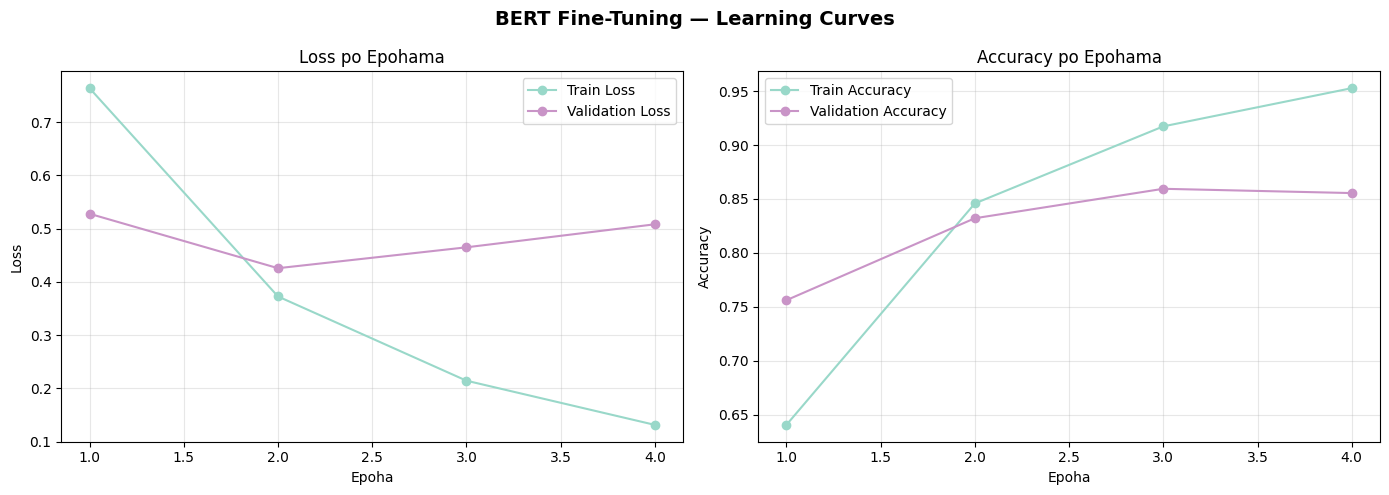

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
epochs_range = range(1, EPOCHS + 1)
 
# Loss
axes[0].plot(epochs_range, history['train_loss'], 'o-', label='Train Loss',color="#99d8c9")
axes[0].plot(epochs_range, history['val_loss'], 'o-', label='Validation Loss',color='#c994c7')
axes[0].set_title('Loss po Epohama')
axes[0].set_xlabel('Epoha')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
 
# Accuracy
axes[1].plot(epochs_range, history['train_acc'], 'o-', label='Train Accuracy',color="#99d8c9")
axes[1].plot(epochs_range, history['val_acc'],  'o-', label='Validation Accuracy',color='#c994c7')
axes[1].set_title('Accuracy po Epohama')
axes[1].set_xlabel('Epoha')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
 
plt.suptitle('BERT Fine-Tuning — Learning Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/diplomski/plots/bert_learning_curves.png',
            dpi=150, bbox_inches='tight')
plt.show()

Training loss steadily decreases throughout all four epochs, indicating successful optimization of model parameters. Validation loss decreases during the first two epochs but starts increasing afterwards, while validation accuracy improves only marginally.

This pattern suggests the onset of overfitting after the second epoch. The model continues to fit the training data more closely, but generalization performance on unseen validation examples improves only slightly.

The results are consistent with the original BERT fine-tuning recommendations, where 2–4 epochs are typically sufficient for downstream classification tasks.

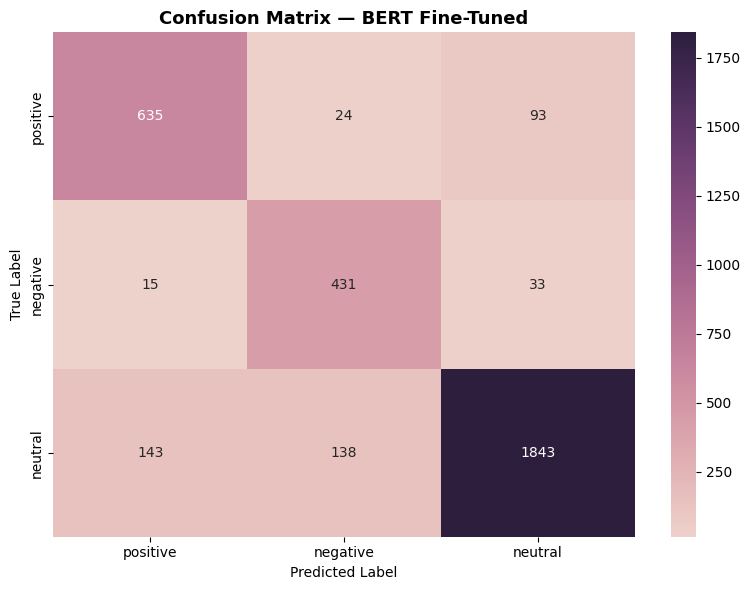

In [25]:
cm = confusion_matrix(
    true_labels_str,
    pred_labels_str,
    labels=['positive', 'negative', 'neutral']
)
 
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['positive', 'negative', 'neutral'],
    yticklabels=['positive', 'negative', 'neutral'],
    cmap=sns.cubehelix_palette(as_cmap=True),
    ax=ax
)
ax.set_title('Confusion Matrix — BERT Fine-Tuned', fontsize=13, fontweight='bold')
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/diplomski/plots/bert_confusion_matrix.png',
            dpi=150, bbox_inches='tight')
plt.show()

Most predictions are concentrated on the main diagonal, indicating a high number of correctly classified examples.

The majority of misclassifications involve neutral examples being predicted as either positive or negative. Direct confusion between positive and negative sentiment is relatively rare, suggesting that the model effectively distinguishes strongly polarized sentiment while occasionally struggling with borderline neutral cases.

In [26]:
del model
torch.cuda.empty_cache()

##### Save BERT results in MLflow

In [3]:
import pandas as pd
import mlflow

mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("sentiment_analysis_model_comparison")

bert_metrics = pd.read_csv("results/bert_metrics.csv").iloc[0]

with mlflow.start_run(run_name="bert_base_uncased_finetuned"):

    mlflow.log_param("model", bert_metrics["model"])
    mlflow.log_param("hardware", bert_metrics["hardware"])

    mlflow.log_metric("accuracy", bert_metrics["accuracy"])
    mlflow.log_metric("macro_f1", bert_metrics["macro_f1"])
    mlflow.log_metric("macro_precision", bert_metrics["macro_precision"])
    mlflow.log_metric("macro_recall", bert_metrics["macro_recall"])

    mlflow.log_metric("n_parameters", bert_metrics["parameters"])
    mlflow.log_metric("model_size_mb", bert_metrics["model_size_mb"])

    mlflow.log_metric("train_time_sec", bert_metrics["training_time_sec"])
    mlflow.log_metric("inference_time_sec", bert_metrics["inference_time_sec"])
    mlflow.log_metric(
        "inference_ms_per_sample",
        bert_metrics["inference_time_per_sample_ms"]
    )
    mlflow.log_metric("samples_per_second", bert_metrics["bert_samples_per_second"])

    mlflow.log_metric("epochs", bert_metrics["epochs"])
    mlflow.log_metric("batch_size", bert_metrics["batch_size"])
    mlflow.log_metric("max_length", bert_metrics["max_length"])
    mlflow.log_metric("learning_rate", bert_metrics["learning_rate"])

    mlflow.log_metric("peak_gpu_memory_mb", bert_metrics["peak_gpu_memory_mb"])

